### Tasks:
1. Data Import and Cleaning:

    - Import the dataset using Pandas.
    - Clean and preprocess the data, addressing missing values and categorizing data as needed.
    - Convert dates and other relevant fields to appropriate formats.

2. Exploratory Data Analysis:

    - Use Pandas to explore basic statistics such as the number of crashes, fatalities, and survival rates.
    - Analyze the frequency of crashes over time to identify any trends.

3. Statistical Analysis:

    - Apply SciPy to analyze the distribution of fatalities and survival rates. Calculate key statistics like mean, median, and standard deviation.
    - Conduct a hypothesis test (e.g., comparing the average number of fatalities in different decades or regions).

4. Visualization:

    - Create charts and graphs using Matplotlib and Seaborn to visualize the findings from your exploratory data analysis and statistical tests.
    - Examples might include time series plots of crashes over years, bar charts of crashes by region, and histograms of fatalities.

5. Insight and Report:

    - Summarize your findings and provide insights into the patterns or anomalies discovered in the data.
    - Prepare a well-structured report including all code, visualizations, and interpretations.


### Solution

In [153]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [154]:
df = pd.read_csv(
    "data/Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv",
    encoding="latin1"
)

display(df.head(5))

,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,9/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,9/7/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,7/12/1912,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,8/6/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,9/9/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...


In [155]:
df.shape

(4998, 17)

In [156]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   4998 non-null   str    
 1   Time                   3486 non-null   str    
 2   Location               4994 non-null   str    
 3   Operator               4988 non-null   str    
 4   Flight #               1329 non-null   str    
 5   Route                  4221 non-null   str    
 6   AC Type                4983 non-null   str    
 7   Registration           4724 non-null   str    
 8   cn/ln                  4330 non-null   str    
 9   Aboard                 4980 non-null   float64
 10  Aboard Passangers      4769 non-null   float64
 11  Aboard Crew            4772 non-null   float64
 12  Fatalities             4990 non-null   float64
 13  Fatalities Passangers  4756 non-null   float64
 14  Fatalities Crew        4757 non-null   float64
 15  Ground         

In [157]:
# Drop columns not relevant to the analysis
df = df.drop(columns=['Time','Operator', 'Route', 'AC Type', 'Flight #', 'Registration', 'cn/ln', 'Ground', 'Summary'])

In [158]:
# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Check if dates were converted properly
print(f"Nulls after datetime transformation: {df['Date'].isna().sum()}")

# Create Year and Decade columns for testing trends later
df["Year"] = df["Date"].dt.year
df["Decade"] = (df["Year"] // 10) * 10

# Create columns for suvivals and survival rate
df["Survivors"] = df["Aboard"] - df["Fatalities"]
df["Survival_Rate"] = df["Survivors"] / df["Aboard"]

Nulls after datetime transformation: 0


In [159]:
# Check number of nulls in each column
df.isna().sum()

Date                       0
Location                   4
Aboard                    18
Aboard Passangers        229
Aboard Crew              226
Fatalities                 8
Fatalities Passangers    242
Fatalities Crew          241
Year                       0
Decade                     0
Survivors                 18
Survival_Rate             23
dtype: int64

In [160]:
# Drop null rows with insignificant statistical impact 
df = df.dropna(subset=["Aboard", "Fatalities", "Location"])

In [161]:
total_crashes = len(df)
total_fatalities = df["Fatalities"].sum()
mean_fatalities = df["Fatalities"].mean()
median_fatalities = df["Fatalities"].median()
std_fatalities = df["Fatalities"].std()
skew_fatalities = stats.skew(df["Fatalities"])

print(f"total number of crashes:{total_crashes}")
print(f"total number of fatalities: {total_fatalities}")
print(f"fatalities mean: {mean_fatalities.round(2)}")
print(f"fatalities median: {median_fatalities}")
print(f"standard deviation of fatalities: {std_fatalities.round(2)}")
print(f"fatilities skewness: {skew_fatalities.round(2)}")


total number of crashes:4976
total number of fatalities: 111544.0
fatalities mean: 22.42
fatalities median: 11.0
standard deviation of fatalities: 35.1
fatilities skewness: 4.6


In [162]:
# Check survival rate
df["Survival_Rate"].describe()

count    4971.000000
mean        0.181467
std         0.311788
min         0.000000
25%         0.000000
50%         0.000000
75%         0.250000
max         1.000000
Name: Survival_Rate, dtype: float64

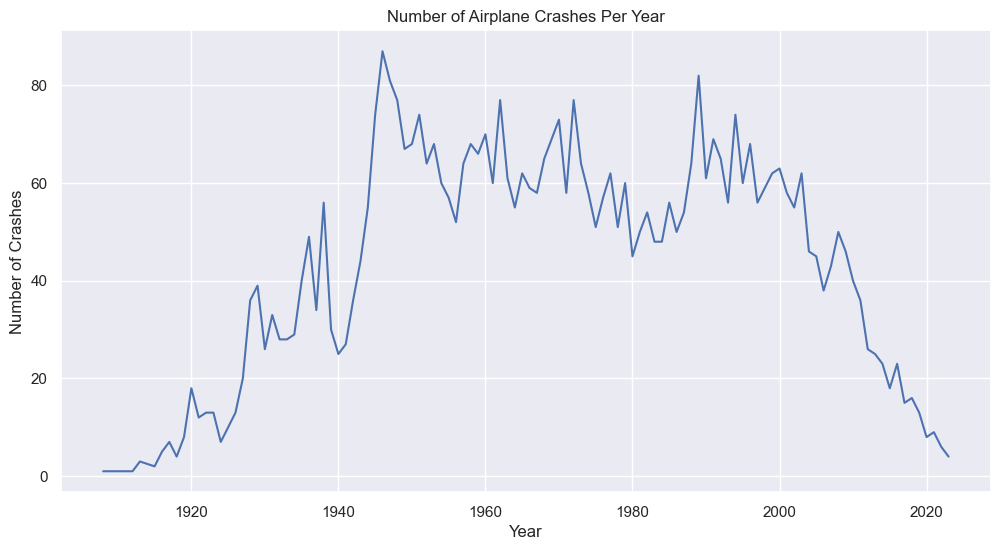

In [163]:
crashes_per_year = df.groupby("Year").size()

# Plot time series of crashes per year
plt.figure(figsize=(12,6))
plt.plot(crashes_per_year.index, crashes_per_year.values)
plt.title("Number of Airplane Crashes Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Crashes")
plt.show()

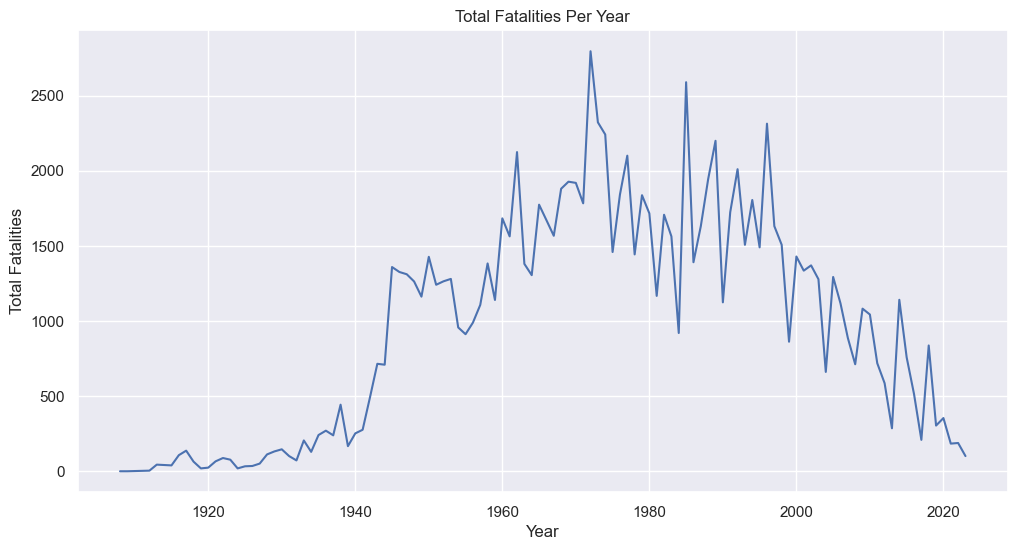

In [164]:
fatalities_per_year = df.groupby("Year")["Fatalities"].sum()

# Plot a time series of fatalities per year
plt.figure(figsize=(12,6))
plt.plot(fatalities_per_year.index, fatalities_per_year.values)
plt.title("Total Fatalities Per Year")
plt.xlabel("Year")
plt.ylabel("Total Fatalities")
plt.show()

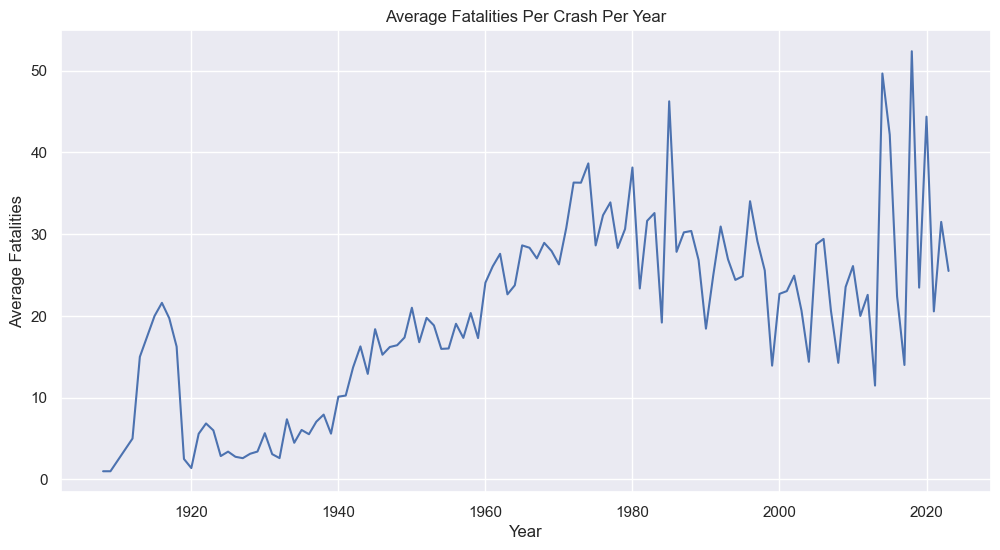

In [165]:
avg_fatalities_per_year = df.groupby("Year")["Fatalities"].mean()

# Plot a time series of avarage fatalities per crash per year
plt.figure(figsize=(12,6))
plt.plot(avg_fatalities_per_year.index, avg_fatalities_per_year.values)
plt.title("Average Fatalities Per Crash Per Year")
plt.xlabel("Year")
plt.ylabel("Average Fatalities")
plt.show()

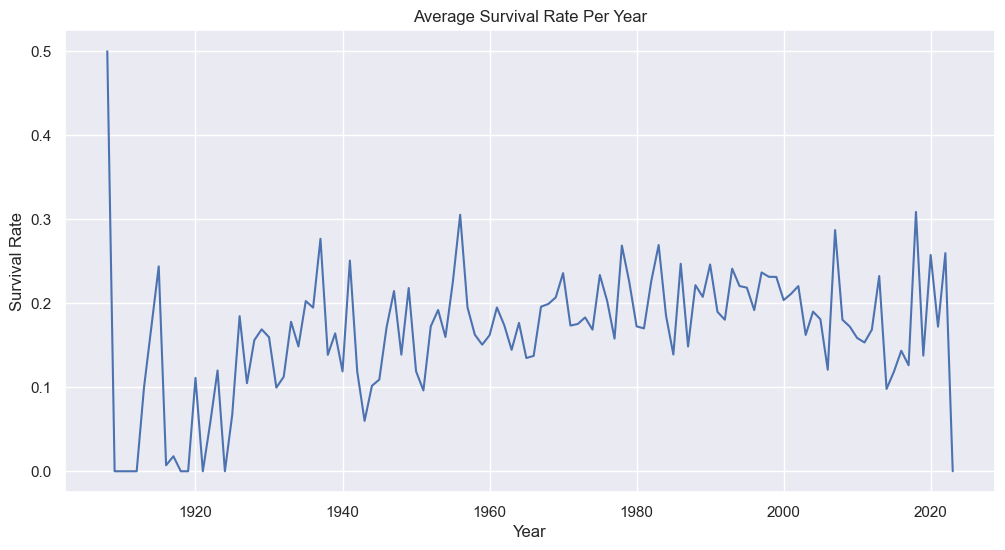

In [166]:
survival_per_year = df.groupby("Year")["Survival_Rate"].mean()

# Plot a time series of a mean survival rate per year
plt.figure(figsize=(12,6))
plt.plot(survival_per_year.index, survival_per_year.values)
plt.title("Average Survival Rate Per Year")
plt.xlabel("Year")
plt.ylabel("Survival Rate")
plt.show()

**Observation**: The frequency of recorded crashes increased substantially during the mid-20th century, corresponding to the rapid expansion of commercial aviation. However, in recent decades, both the number of crashes and the average fatalities per crash have declined, suggesting improvements in aviation safety.

In [167]:
fatalities = df["Fatalities"].dropna()
survival = df["Survival_Rate"].dropna()

# Mean
mean_fat_scipy = stats.tmean(fatalities)
# Standard deviation
std_fat_scipy = stats.tstd(fatalities)
# Median
median_fat_scipy = stats.scoreatpercentile(fatalities, 50)

print(f"mean fatalitities (SciPy): {mean_fat_scipy.round(2)}")
print(f"standard deviation for fatalitities (SciPy): {std_fat_scipy.round(2)}")
print(f"median for fatalitities (SciPy): {median_fat_scipy}\n")

# Mean
mean_surv_scipy = stats.tmean(survival)
# Standard deviation
std_surv_scipy = stats.tstd(survival)
# Median
median_surv_scipy = stats.scoreatpercentile(survival, 50)

print(f"mean survival (SciPy): {mean_surv_scipy.round(2)}")
print(f"standard deviation for survival (SciPy): {std_surv_scipy.round(2)}")
print(f"median for survival (SciPy): {median_surv_scipy}")


mean fatalitities (SciPy): 22.42
standard deviation for fatalitities (SciPy): 35.1
median for fatalitities (SciPy): 11.0

mean survival (SciPy): 0.18
standard deviation for survival (SciPy): 0.31
median for survival (SciPy): 0.0


In [168]:
skew_fatalities = stats.skew(fatalities)
kurtosis_fatalities = stats.kurtosis(fatalities)

print(f"skew for fatalities: {skew_fatalities.round(2)}")
print(f"kurtosis for fatalities: {kurtosis_fatalities.round(2)}")

skew for fatalities: 4.6
kurtosis for fatalities: 36.51


In [169]:
# Compare the average number of fatalities prior to 1950 and after 1950
pre_1950 = df[df["Year"] < 1950]["Fatalities"]
post_1950 = df[df["Year"] >= 1950]["Fatalities"]

# Use a non-parametric test (because of skewness)
p_value = stats.mannwhitneyu(pre_1950, post_1950).pvalue

alpha = 0.05
if p_value < alpha:
    print(f"p={p_value:.4f} < {alpha} → REJECT H0")
    print("The second half of the 20th century produced a significant change in the rate of fatalities in aviation.")
else:
    print(f"p={p_value:.4f} >= {alpha} → Fail to reject H0")
    print("No significant difference between pre- and post-1950 rate of fatalities.")
print()

p=0.0000 < 0.05 → REJECT H0
The second half of the 20th century produced a significant change in the rate of fatalities in aviation.



**Observation**: While crash frequency peaked mid-century, this likely reflects expansion in air travel rather than declining safety standards.

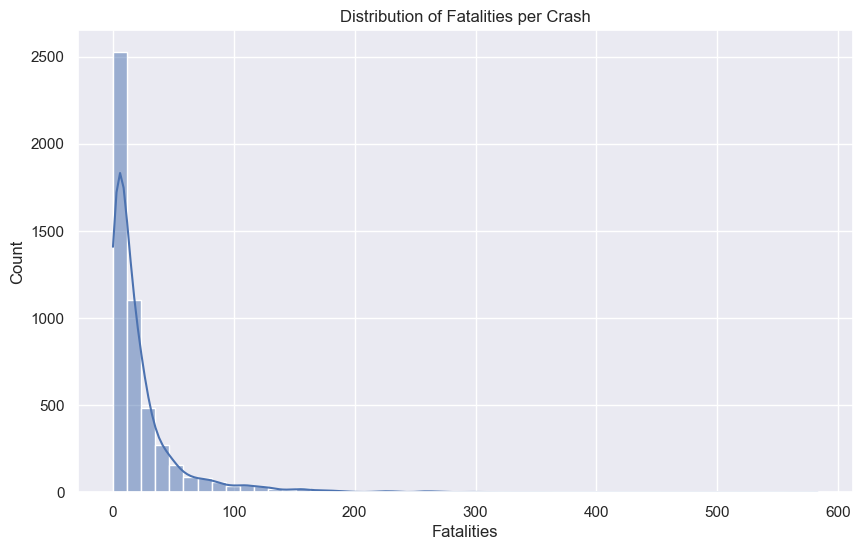

In [170]:
sns.set_theme()

plt.figure(figsize=(10, 6))
sns.histplot(df["Fatalities"], bins=50, kde=True)
plt.title("Distribution of Fatalities per Crash")
plt.xlabel("Fatalities")
plt.ylabel("Count")
plt.show()

**Observation**: Since the data on fatalities is heavily skewed, we use a log scale on the x-axis in the next histogram for the same dataset.

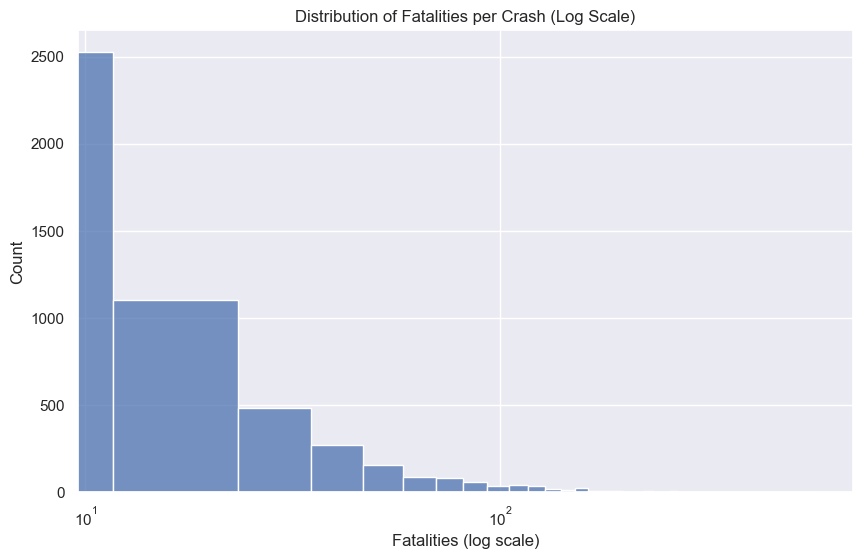

In [171]:
plt.figure(figsize=(10, 6))
sns.histplot(df["Fatalities"], bins=50, kde=False)
plt.xscale("log")
plt.title("Distribution of Fatalities per Crash (Log Scale)")
plt.xlabel("Fatalities (log scale)")
plt.ylabel("Count")
plt.show()

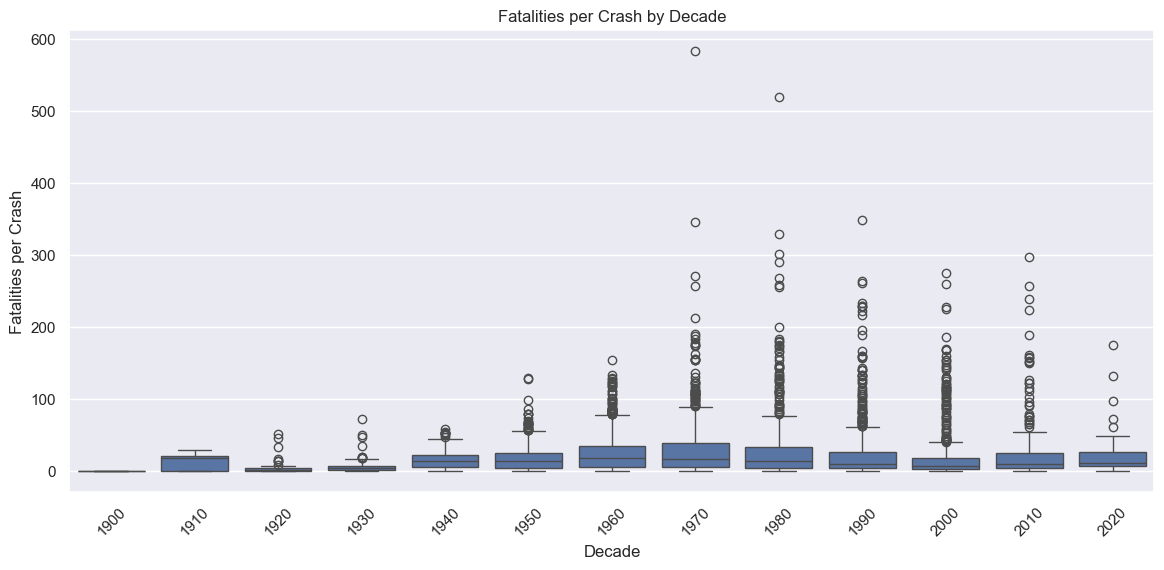

In [172]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x="Decade", y="Fatalities")
plt.title("Fatalities per Crash by Decade")
plt.xlabel("Decade")
plt.ylabel("Fatalities per Crash")
plt.xticks(rotation=45)
plt.show()

**Observation**: Since outliers clearly dominate in the boxplot above, we opt for a y-axis log-scaled boxplot below.

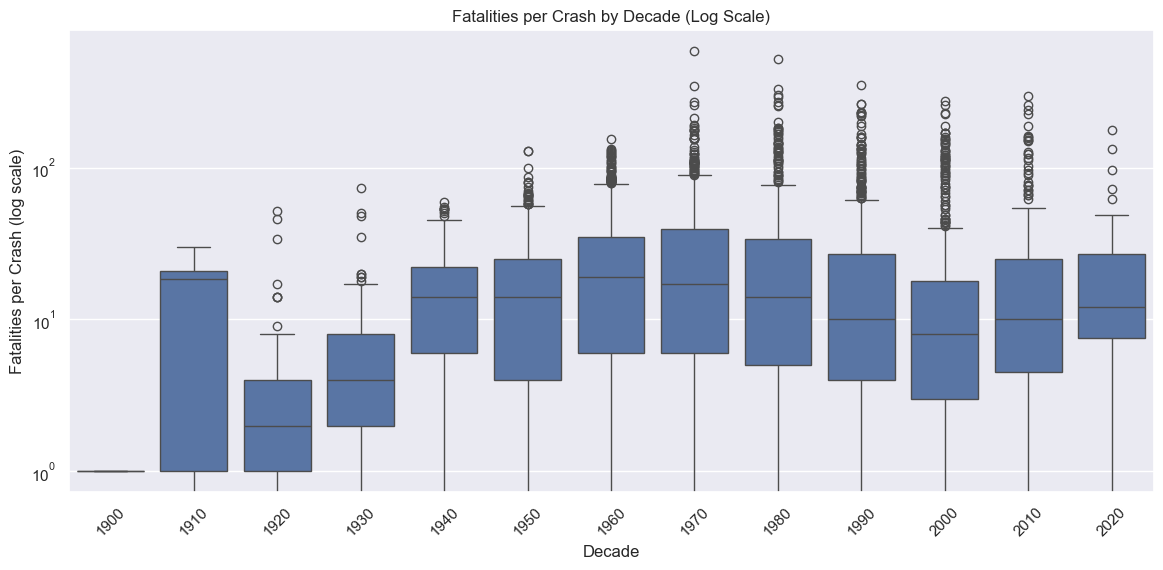

In [173]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x="Decade", y="Fatalities")
plt.yscale("log")
plt.title("Fatalities per Crash by Decade (Log Scale)")
plt.xlabel("Decade")
plt.ylabel("Fatalities per Crash (log scale)")
plt.xticks(rotation=45)
plt.show()

**Observation**: The log-scaled boxplot reveals a clear structural shift in the mid-20th century, with median fatalities per crash increasing significantly during the 1940s–1970s. This likely reflects the expansion of commercial aviation and increased aircraft capacity. In more recent decades, median fatalities per crash appear to decline, suggesting improvements in aviation safety and survivability. However, the distribution remains heavily right-skewed across all decades, with rare but extreme high-fatality events exerting strong influence.